# Badanie odporności modelu na kontrolowane warunki oświetleniowe

Celem eksperymentu jest określenie wpływu kontrolowanej zmiany warunków oświetleniowych na skuteczność klasyfikacji znaków drogowych.

W badaniu wykorzystano wytrenowany model `ResNet50` oraz strategię `WeightedRandomSampler` ustaloną w poprzednich eksperymentach.

Dla każdego obrazu generowane są kontrolowane warianty o zmniejszonej i zwiększonej jasności.

Badanie obejmuje:

- wariant bazowy bez modyfikacji,
- trzy poziomy zaciemnienia,
- trzy poziomy zwiększenia jasności.

Wszystkie warianty zachowują pierwotną klasę obrazu.

Zbiór walidacyjny jest wykorzystywany do analizy odporności oraz wyboru metody preprocessingu. Niezależny zbiór `test_final` nie jest wykorzystywany na tym etapie.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
)

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_ORDER,
    LIGHTING_FACTORS,
)

from src.data.preprocessing import (
    build_preprocessing_eval_transform,
)

from src.models.resnet50 import (
    create_resnet50,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "lighting_analysis"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


for directory in [
    METRICS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Manifesty danych

In [2]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "VALIDATION:",
    len(validation_df)
)

Liczba klas: 92
VALIDATION: 2512


## 2. Wczytanie najlepszego modelu bazowego


In [3]:
checkpoint_path = (
    CHECKPOINT_DIR
    / "resnet50_finetuned_best.pt"
)


if not checkpoint_path.exists():

    raise FileNotFoundError(
        f"Brak checkpointu: "
        f"{checkpoint_path}"
    )


model = create_resnet50(
    num_classes=len(
        class_codes
    ),
    pretrained=False,
)


state_dict = torch.load(
    checkpoint_path,
    map_location=DEVICE,
)


model.load_state_dict(
    state_dict
)

model = model.to(
    DEVICE
)

model.eval()


print(
    "Wczytano ResNet50."
)

Wczytano ResNet50.


## 3. Wizualizacja kontrolowanych zmian oświetlenia

Dla pojedynczego obrazu przedstawiono jego oryginalną wersję oraz kontrolowane warianty o zmniejszonej i zwiększonej jasności.

Celem jest wizualna kontrola zakresu zastosowanych modyfikacji.

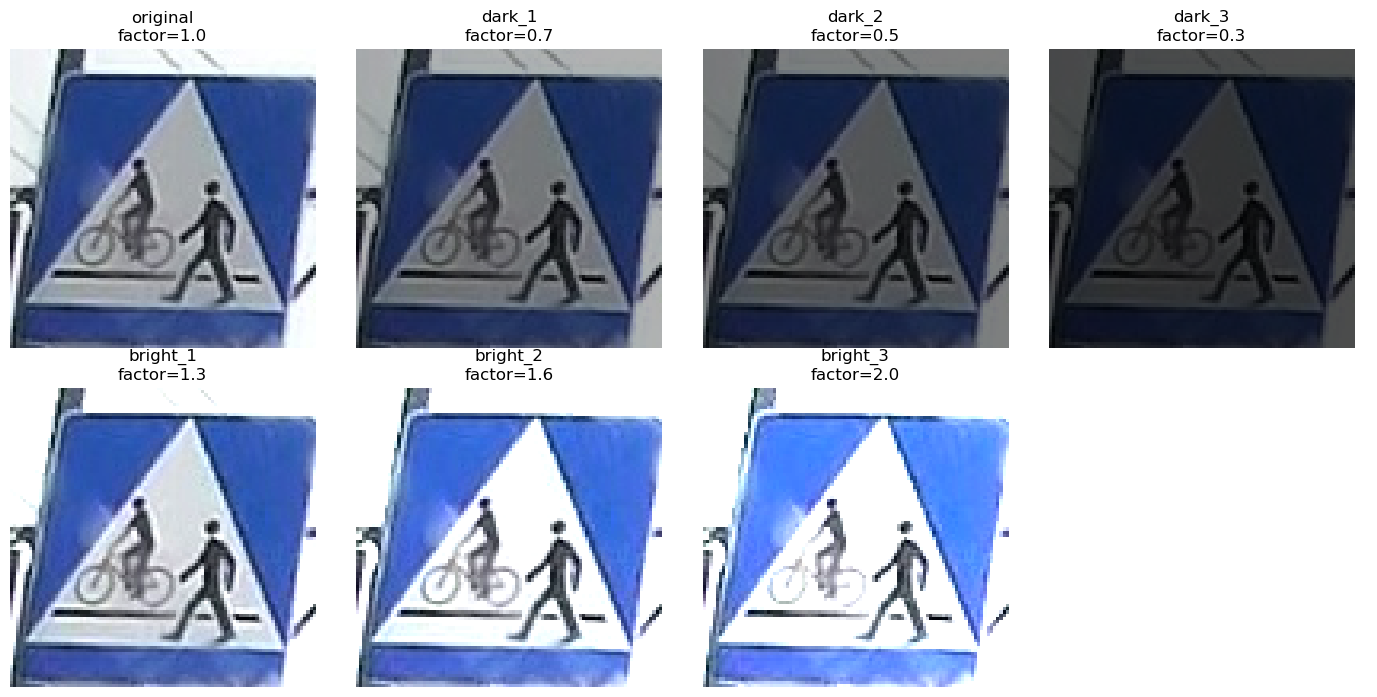

In [4]:
from PIL import Image


sample_path = Path(
    validation_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)


axes = axes.reshape(-1)


for axis, variant in zip(
    axes,
    LIGHTING_ORDER,
):

    from src.data.lighting_augmentation import (
        apply_lighting_variant,
    )

    variant_image = (
        apply_lighting_variant(
            sample_image,
            variant,
        )
    )

    axis.imshow(
        variant_image
    )

    axis.set_title(
        f"{variant}\n"
        f"factor={LIGHTING_FACTORS[variant]}"
    )

    axis.axis(
        "off"
    )


for axis in axes[
    len(LIGHTING_ORDER):
]:

    axis.axis(
        "off"
    )


plt.tight_layout()
plt.show()

## 4. Funkcja oceny modelu dla określonego wariantu oświetlenia

In [5]:
def evaluate_lighting_variant(
    model,
    manifest_path,
    variant,
    preprocessing="original",
):

    transform = (
        build_preprocessing_eval_transform(
            preprocessing,
            image_size=224,
        )
    )


    dataset = (
        ControlledLightingDataset(
            manifest_path,
            class_to_idx,
            lighting_variant=variant,
            transform=transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "variant": variant,
        "factor": LIGHTING_FACTORS[
            variant
        ],
        "preprocessing": preprocessing,
        "samples": len(dataset),
        "accuracy": metrics[
            "accuracy"
        ],
        "macro_precision": metrics[
            "macro_precision"
        ],
        "macro_recall": metrics[
            "macro_recall"
        ],
        "macro_f1": metrics[
            "macro_f1"
        ],
        "inference_time_seconds":
            inference_time,
        "y_true": y_true,
        "y_pred": y_pred,
    }

## 5. Bazowa odporność ResNet50 na kontrolowane zmiany oświetlenia

W pierwszej fazie oceniany jest model bez dodatkowego preprocessingu. Badanie obejmuje wszystkie zdefiniowane warianty oświetlenia.

In [6]:
robustness_results = []


for variant in LIGHTING_ORDER:

    print(
        f"Ocena wariantu: {variant}"
    )

    result = evaluate_lighting_variant(
        model=model,
        manifest_path=VALIDATION_PATH,
        variant=variant,
        preprocessing="original",
    )

    robustness_results.append(
        result
    )


robustness_df = pd.DataFrame(
    [
        {
            key: value
            for key, value in result.items()
            if key not in [
                "y_true",
                "y_pred",
            ]
        }
        for result
        in robustness_results
    ]
)


display(
    robustness_df
)

Ocena wariantu: original
Ocena wariantu: dark_1
Ocena wariantu: dark_2
Ocena wariantu: dark_3
Ocena wariantu: bright_1
Ocena wariantu: bright_2
Ocena wariantu: bright_3


,variant,factor,preprocessing,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,1.0,original,2512,0.925159,0.918182,0.926999,0.918303,198.858597
1,dark_1,0.7,original,2512,0.917596,0.912998,0.917195,0.910110,216.589021
2,dark_2,0.5,original,2512,0.907245,0.890015,0.902630,0.891392,202.953606
3,dark_3,0.3,original,2512,0.872611,0.871220,0.872553,0.859199,195.758301
4,bright_1,1.3,original,2512,0.926354,0.914991,0.915438,0.911086,193.885136
5,bright_2,1.6,original,2512,0.907643,0.895429,0.899882,0.889274,195.006402
6,bright_3,2.0,original,2512,0.878583,0.846223,0.868954,0.844818,205.936137


In [7]:
robustness_df.to_csv(
    METRICS_DIR
    / "lighting_robustness_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

## 6. Wpływ poziomu oświetlenia na skuteczność klasyfikacji

Porównanie macro F1 dla kolejnych poziomów zaciemnienia i zwiększenia jasności pozwala określić kierunek oraz skalę pogorszenia skuteczności modelu.

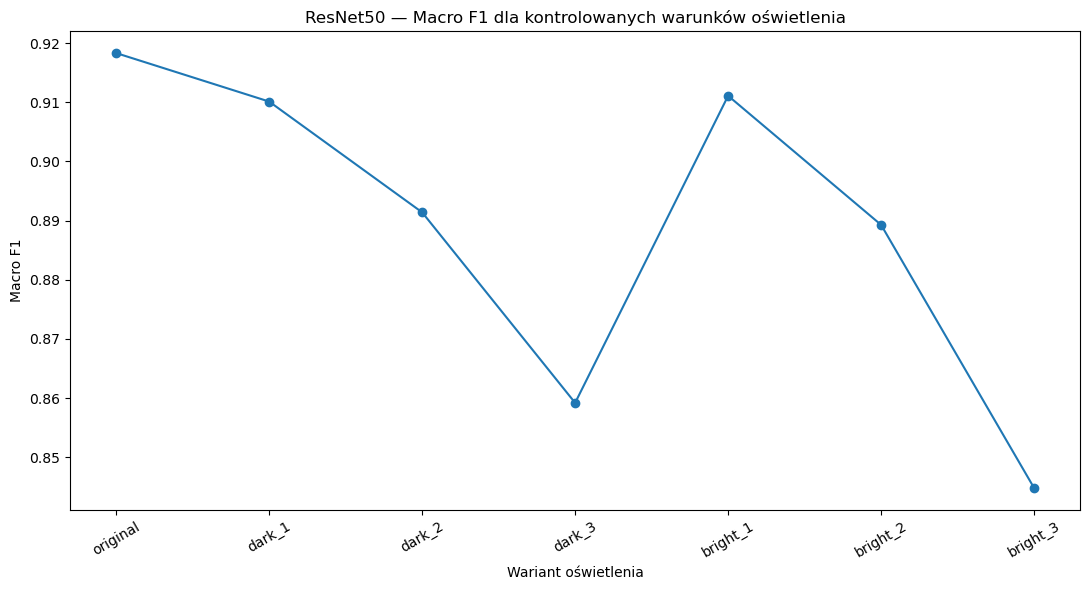

In [8]:
plot_df = robustness_df.copy()


fig, ax = plt.subplots(
    figsize=(11, 6)
)


ax.plot(
    plot_df[
        "variant"
    ],
    plot_df[
        "macro_f1"
    ],
    marker="o",
)


ax.set_title(
    "ResNet50 — Macro F1 dla kontrolowanych warunków oświetlenia"
)

ax.set_xlabel(
    "Wariant oświetlenia"
)

ax.set_ylabel(
    "Macro F1"
)


plt.xticks(
    rotation=30
)

plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_resnet50_lighting_robustness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 7. Analiza degradacji dla zaciemnienia

Głównym przedmiotem dalszego eksperymentu jest zaciemnienie obrazu, ponieważ wcześniejsza analiza danych naturalnych wskazała na większe pogorszenie skuteczności w warunkach niskiej jasności.

Jako poziomy kontrolowanego zaciemnienia przyjęto `dark_1`, `dark_2` i `dark_3`.

In [9]:
original_f1 = float(
    robustness_df[
        robustness_df[
            "variant"
        ]
        == "original"
    ][
        "macro_f1"
    ].iloc[0]
)


dark_results = robustness_df[
    robustness_df[
        "variant"
    ].isin(
        [
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
].copy()


dark_results[
    "f1_drop_from_original"
] = (
    original_f1
    - dark_results[
        "macro_f1"
    ]
)


display(
    dark_results
)

,variant,factor,preprocessing,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds,f1_drop_from_original
1,dark_1,0.7,original,2512,0.917596,0.912998,0.917195,0.910110,216.589021,0.008193
2,dark_2,0.5,original,2512,0.907245,0.890015,0.902630,0.891392,202.953606,0.026911
3,dark_3,0.3,original,2512,0.872611,0.871220,0.872553,0.859199,195.758301,0.059104


## 8. Analiza wyników dla poszczególnych klas

Porównanie wyników klas dla oryginalnego obrazu i silnego zaciemnienia pozwala określić, które klasy są najbardziej podatne na zmianę warunków oświetleniowych.

In [10]:
original_result = next(
    result
    for result in robustness_results
    if result["variant"] == "original"
)


dark3_result = next(
    result
    for result in robustness_results
    if result["variant"] == "dark_3"
)


target_names = [
    idx_to_class[index]
    for index in range(
        len(class_codes)
    )
]


original_report = pd.DataFrame(
    classification_report(
        original_result[
            "y_true"
        ],
        original_result[
            "y_pred"
        ],
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


dark3_report = pd.DataFrame(
    classification_report(
        dark3_result[
            "y_true"
        ],
        dark3_result[
            "y_pred"
        ],
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


original_report = (
    original_report
    .iloc[:len(class_codes)]
    .copy()
)


dark3_report = (
    dark3_report
    .iloc[:len(class_codes)]
    .copy()
)


class_degradation = pd.DataFrame(
    {
        "class_code":
            target_names,

        "original_f1":
            original_report[
                "f1-score"
            ].to_numpy(),

        "dark3_f1":
            dark3_report[
                "f1-score"
            ].to_numpy(),
    }
)


class_degradation[
    "f1_change"
] = (
    class_degradation[
        "dark3_f1"
    ]
    -
    class_degradation[
        "original_f1"
    ]
)


display(
    class_degradation.sort_values(
        "f1_change"
    ).head(20)
)

,class_code,original_f1,dark3_f1,f1_change
55,C-6,0.800000,0.400000,-0.400000
62,D-18b,0.857143,0.500000,-0.357143
35,B-34,1.000000,0.666667,-0.333333
5,A-15,1.000000,0.666667,-0.333333
38,B-42,0.900000,0.608696,-0.291304
69,D-26b,0.857143,0.571429,-0.285714
71,D-27,1.000000,0.727273,-0.272727
25,B-1,1.000000,0.769231,-0.230769
45,C-10,0.873786,0.656716,-0.217070
47,C-13,1.000000,0.800000,-0.200000


## 9. Test metod preprocessingu dla warunków zaciemnienia

Na podstawie wyników bazowego eksperymentu przeprowadzana jest ocena metod preprocessingu dla trzech poziomów zaciemnienia.

Porównano:

- obraz oryginalny,
- korekcję gamma,
- wyrównanie histogramu,
- CLAHE.

Do wyboru metody wykorzystywany jest wyłącznie zbiór walidacyjny.

In [11]:
preprocessing_methods = [
    "original",
    "gamma",
    "histogram_equalization",
    "clahe",
]


dark_variants = [
    "dark_1",
    "dark_2",
    "dark_3",
]


preprocessing_results = []


for method in preprocessing_methods:

    for variant in dark_variants:

        print(
            f"Metoda: {method} | "
            f"Wariant: {variant}"
        )

        result = evaluate_lighting_variant(
            model=model,
            manifest_path=VALIDATION_PATH,
            variant=variant,
            preprocessing=method,
        )

        preprocessing_results.append(
            {
                key: value
                for key, value
                in result.items()
                if key not in [
                    "y_true",
                    "y_pred",
                ]
            }
        )


preprocessing_df = pd.DataFrame(
    preprocessing_results
)


display(
    preprocessing_df
)

Metoda: original | Wariant: dark_1
Metoda: original | Wariant: dark_2
Metoda: original | Wariant: dark_3
Metoda: gamma | Wariant: dark_1
Metoda: gamma | Wariant: dark_2
Metoda: gamma | Wariant: dark_3
Metoda: histogram_equalization | Wariant: dark_1
Metoda: histogram_equalization | Wariant: dark_2
Metoda: histogram_equalization | Wariant: dark_3
Metoda: clahe | Wariant: dark_1
Metoda: clahe | Wariant: dark_2
Metoda: clahe | Wariant: dark_3


,variant,factor,preprocessing,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,dark_1,0.7,original,2512,0.917596,0.912998,0.917195,0.910110,204.382795
1,dark_2,0.5,original,2512,0.907245,0.890015,0.902630,0.891392,193.677156
2,dark_3,0.3,original,2512,0.872611,0.871220,0.872553,0.859199,199.849019
3,dark_1,0.7,gamma,2512,0.898487,0.880475,0.897673,0.880895,222.944663
4,dark_2,0.5,gamma,2512,0.891322,0.891201,0.894955,0.883147,200.157546
5,dark_3,0.3,gamma,2512,0.866640,0.867424,0.857384,0.842306,203.810966
6,dark_1,0.7,histogram_equalization,2512,0.791003,0.782879,0.788064,0.755340,198.763861
7,dark_2,0.5,histogram_equalization,2512,0.773089,0.764221,0.764244,0.730285,194.906595
8,dark_3,0.3,histogram_equalization,2512,0.738057,0.742152,0.731896,0.692482,194.109345
9,dark_1,0.7,clahe,2512,0.818073,0.791135,0.804179,0.763752,195.480333


In [12]:
preprocessing_df.to_csv(
    METRICS_DIR
    / "preprocessing_lighting_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

## 10. Wybór metody preprocessingu

Podstawowym kryterium wyboru jest średnia wartość macro F1 uzyskana dla trzech poziomów zaciemnienia.

Wyniki dla obrazu oryginalnego stanowią punkt odniesienia, natomiast wyniki dla grup `normal` i `bright` zostaną wykorzystane do dodatkowej kontroli wpływu wybranej metody na pozostałe warunki.

In [13]:
dark_method_summary = (
    preprocessing_df
    .groupby(
        "preprocessing"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        min_dark_macro_f1=(
            "macro_f1",
            "min",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    dark_method_summary
)


best_preprocessing = (
    dark_method_summary
    .index[0]
)


print(
    "Wybrana metoda:",
    best_preprocessing
)

,mean_dark_macro_f1,min_dark_macro_f1,mean_dark_accuracy
preprocessing,,,
original,0.886900,0.859199,0.899151
gamma,0.868783,0.842306,0.885483
clahe,0.758345,0.745179,0.809050
histogram_equalization,0.726036,0.692482,0.767383


Wybrana metoda: original


## 11. Kontrola wybranej metody na pozostałych warunkach

Wybrana metoda jest dodatkowo oceniana na obrazie oryginalnym oraz na wariantach zwiększonej jasności.

Celem jest sprawdzenie, czy poprawa skuteczności w warunkach zaciemnienia nie jest związana z istotnym pogorszeniem wyników dla pozostałych warunków.

In [14]:
control_variants = [
    "original",
    "bright_1",
    "bright_2",
    "bright_3",
]


control_results = []


for variant in control_variants:

    print(
        f"Kontrola: {variant}"
    )

    result = evaluate_lighting_variant(
        model=model,
        manifest_path=VALIDATION_PATH,
        variant=variant,
        preprocessing=best_preprocessing,
    )

    control_results.append(
        {
            key: value
            for key, value
            in result.items()
            if key not in [
                "y_true",
                "y_pred",
            ]
        }
    )


control_df = pd.DataFrame(
    control_results
)


display(
    control_df
)

Kontrola: original
Kontrola: bright_1
Kontrola: bright_2
Kontrola: bright_3


,variant,factor,preprocessing,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,1.0,original,2512,0.925159,0.918182,0.926999,0.918303,204.196625
1,bright_1,1.3,original,2512,0.926354,0.914991,0.915438,0.911086,195.420218
2,bright_2,1.6,original,2512,0.907643,0.895429,0.899882,0.889274,212.004219
3,bright_3,2.0,original,2512,0.878583,0.846223,0.868954,0.844818,222.879562


In [15]:
selection_data = {
    "selected_preprocessing":
        best_preprocessing,

    "selection_metric":
        "mean_dark_macro_f1",

    "validation_dark_results":
        dark_method_summary.reset_index()
        .to_dict(
            orient="records"
        ),

    "validation_control_results":
        control_df.to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "selected_preprocessing.json"
).write_text(
    json.dumps(
        selection_data,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


control_df.to_csv(
    METRICS_DIR
    / "selected_preprocessing_control_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


print(
    json.dumps(
        selection_data,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "selected_preprocessing": "original",
  "selection_metric": "mean_dark_macro_f1",
  "validation_dark_results": [
    {
      "preprocessing": "original",
      "mean_dark_macro_f1": 0.886900298482793,
      "min_dark_macro_f1": 0.8591988964675845,
      "mean_dark_accuracy": 0.8991507430997876
    },
    {
      "preprocessing": "gamma",
      "mean_dark_macro_f1": 0.8687826115050585,
      "min_dark_macro_f1": 0.8423056482937398,
      "mean_dark_accuracy": 0.8854830148619958
    },
    {
      "preprocessing": "clahe",
      "mean_dark_macro_f1": 0.7583448150623373,
      "min_dark_macro_f1": 0.7451787977530353,
      "mean_dark_accuracy": 0.8090498938428875
    },
    {
      "preprocessing": "histogram_equalization",
      "mean_dark_macro_f1": 0.7260358088593343,
      "min_dark_macro_f1": 0.6924822824883742,
      "mean_dark_accuracy": 0.7673832271762208
    }
  ],
  "validation_control_results": [
    {
      "variant": "original",
      "factor": 1.0,
      "preprocessing":

## 12. Porównanie wyników preprocessingu dla zaciemnienia

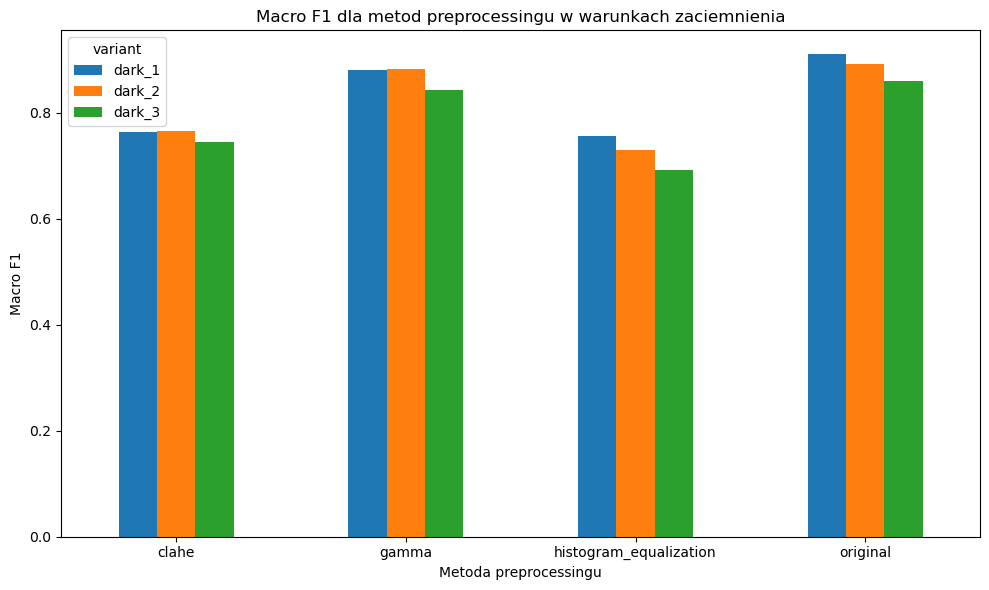

In [16]:
plot_data = (
    preprocessing_df
    .pivot(
        index="preprocessing",
        columns="variant",
        values="macro_f1",
    )
    .reindex(
        columns=[
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


plot_data.plot(
    kind="bar",
    ax=ax,
)


ax.set_title(
    "Macro F1 dla metod preprocessingu "
    "w warunkach zaciemnienia"
)

ax.set_xlabel(
    "Metoda preprocessingu"
)

ax.set_ylabel(
    "Macro F1"
)


plt.xticks(
    rotation=0
)

plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_preprocessing_dark_macro_f1.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()